In [101]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [88]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [89]:
# Dataset paths
train_dir = r"C:\Users\ahmed\Documents\projects\deeplearning project\astronomical recognition\data\raw\Planets and Moons"
test_dir  = r"C:\Users\ahmed\Documents\projects\deeplearning project\astronomical recognition\data\test"

# Output paths
save_model_path = r"C:\Users\ahmed\Documents\projects\deeplearning project\astronomical recognition\results\checkpoints\transfer_learning\best_model.pth"
csv_log_path    = r"C:\Users\ahmed\Documents\projects\deeplearning project\astronomical recognition\results\checkpoints\transfer_learning\training_log.csv"

# Ensure paths exist
for path in [train_dir, test_dir]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Directory not found: {path}")

os.makedirs(os.path.dirname(save_model_path), exist_ok=True)

In [90]:
# Aggressive augmentation for planets
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [91]:
# Create train/val lists per class
train_images = []
val_images = []
class_to_idx = {}
classes = sorted(os.listdir(train_dir))

for idx, cls in enumerate(classes):
    class_to_idx[cls] = idx
    cls_path = os.path.join(train_dir, cls)
    images = [os.path.join(cls_path, f) for f in os.listdir(cls_path)]
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=seed)
    train_images += [(img, idx) for img in train_imgs]
    val_images   += [(img, idx) for img in val_imgs]

print("Classes:", classes)
print("Train samples:", len(train_images))
print("Val samples:", len(val_images))

Classes: ['Earth', 'Jupiter', 'MakeMake', 'Mars', 'Mercury', 'Moon', 'Neptune', 'Pluto', 'Saturn', 'Uranus', 'Venus']
Train samples: 1305
Val samples: 329


In [92]:
class PlanetDataset(Dataset):
    def __init__(self, image_list, transform=None):
        self.image_list = image_list
        self.transform = transform
    
    def __len__(self):
        return len(self.image_list)
    
    def __getitem__(self, idx):
        img_path, label = self.image_list[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = PlanetDataset(train_images, transform=train_transform)
val_ds   = PlanetDataset(val_images, transform=val_transform)
test_ds  = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

In [93]:
# Pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace last layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(classes))
model.fc.requires_grad = True

model = model.to(device)

In [94]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [95]:
epochs = 50
best_acc = 0
patience = 10
counter = 0
history = []

for epoch in range(epochs):
    # Train
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    
    # Validate
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= len(val_loader)
    val_acc = correct / total
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save log
    history.append({"epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss, "val_accuracy": val_acc})
    pd.DataFrame(history).to_csv(csv_log_path, index=False)
    
    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), save_model_path)
        print("✅ Saved Best Model")
        counter = 0
    else:
        counter += 1
    
    # Early stopping
    if counter >= patience:
        print(f"⚠️ Early stopping at epoch {epoch+1}")
        break

Epoch 1/50 | Train Loss: 1.2879 | Val Loss: 0.6622 | Val Acc: 0.9301
✅ Saved Best Model
Epoch 2/50 | Train Loss: 0.3892 | Val Loss: 0.3542 | Val Acc: 0.9453
✅ Saved Best Model
Epoch 3/50 | Train Loss: 0.2562 | Val Loss: 0.2862 | Val Acc: 0.9149
Epoch 4/50 | Train Loss: 0.1798 | Val Loss: 0.2737 | Val Acc: 0.8875
Epoch 5/50 | Train Loss: 0.1368 | Val Loss: 0.1433 | Val Acc: 0.9939
✅ Saved Best Model
Epoch 6/50 | Train Loss: 0.1067 | Val Loss: 0.1398 | Val Acc: 0.9970
✅ Saved Best Model
Epoch 7/50 | Train Loss: 0.1044 | Val Loss: 0.1971 | Val Acc: 0.9392
Epoch 8/50 | Train Loss: 0.0928 | Val Loss: 0.1324 | Val Acc: 0.9848
Epoch 9/50 | Train Loss: 0.0739 | Val Loss: 0.1190 | Val Acc: 0.9666
Epoch 10/50 | Train Loss: 0.0648 | Val Loss: 0.1219 | Val Acc: 0.9818
Epoch 11/50 | Train Loss: 0.0568 | Val Loss: 0.1226 | Val Acc: 0.9787
Epoch 12/50 | Train Loss: 0.0542 | Val Loss: 0.1093 | Val Acc: 0.9787
Epoch 13/50 | Train Loss: 0.0599 | Val Loss: 0.1092 | Val Acc: 0.9787
Epoch 14/50 | Train Los

In [96]:
# Load best model
model.load_state_dict(torch.load(save_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print("Test Accuracy:", test_acc)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_47444\3290077641.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_model_path))


Test Accuracy: 0.6666666666666666


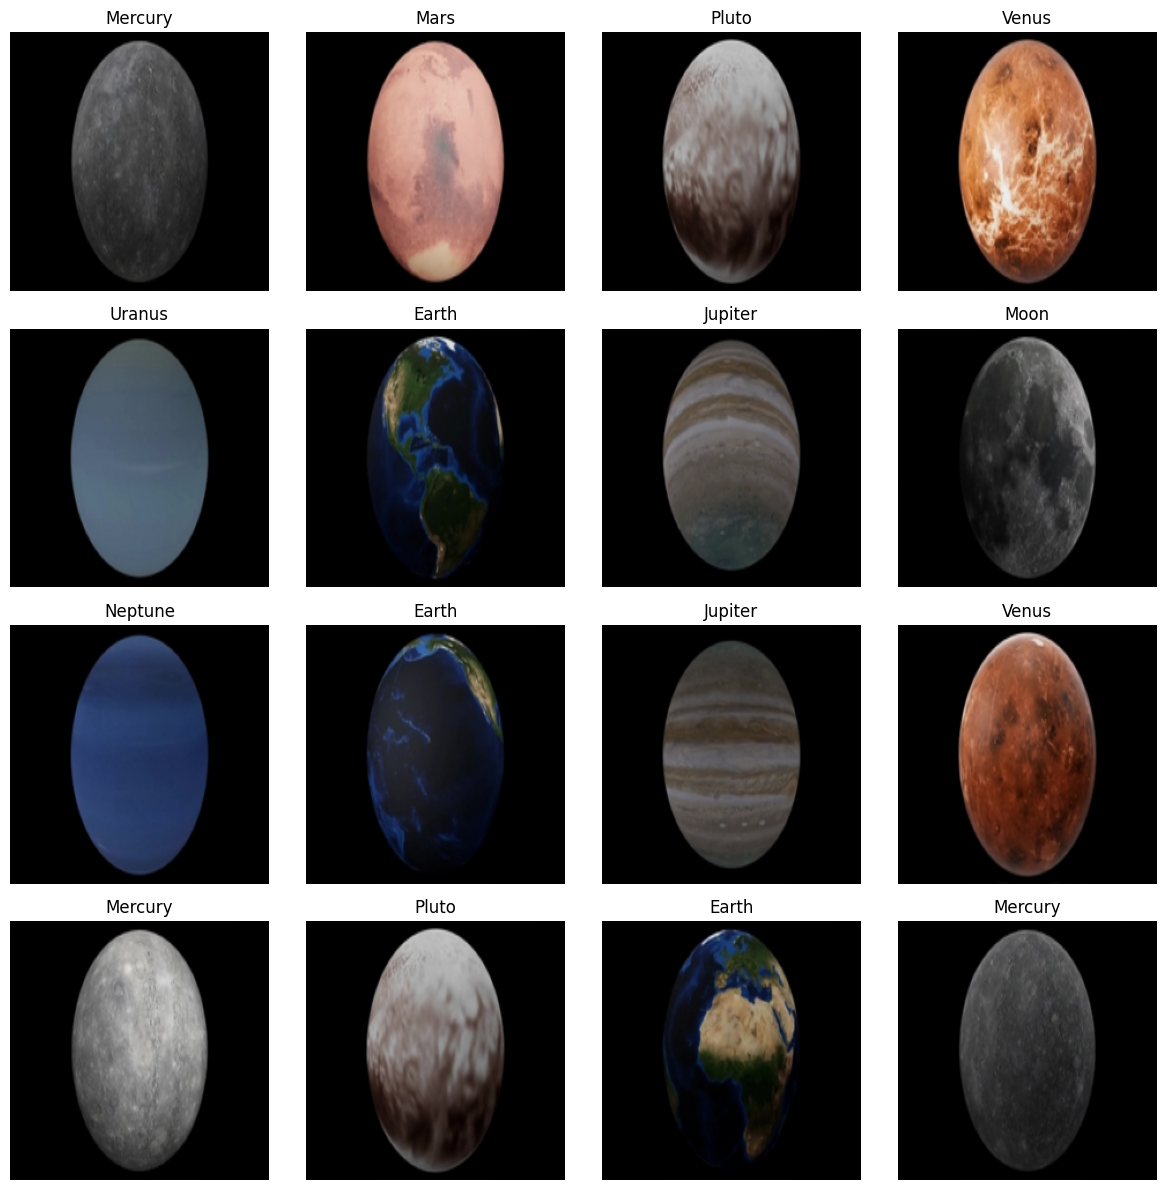

In [98]:
def imshow_planet(img, title=None):
    img = img.numpy().transpose((1,2,0))
    img = np.clip(img * [0.229,0.224,0.225] + [0.485,0.456,0.406], 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.gca().set_aspect('equal', adjustable='box')  # preserve circle shape

# Use val_ds (no heavy augmentation) for visualization
sample_loader = DataLoader(val_ds, batch_size=16, shuffle=True)
images, labels = next(iter(sample_loader))

plt.figure(figsize=(12,12))
for i in range(16):
    plt.subplot(4,4,i+1)
    imshow_planet(images[i], title=classes[labels[i]])
plt.tight_layout()
plt.show()

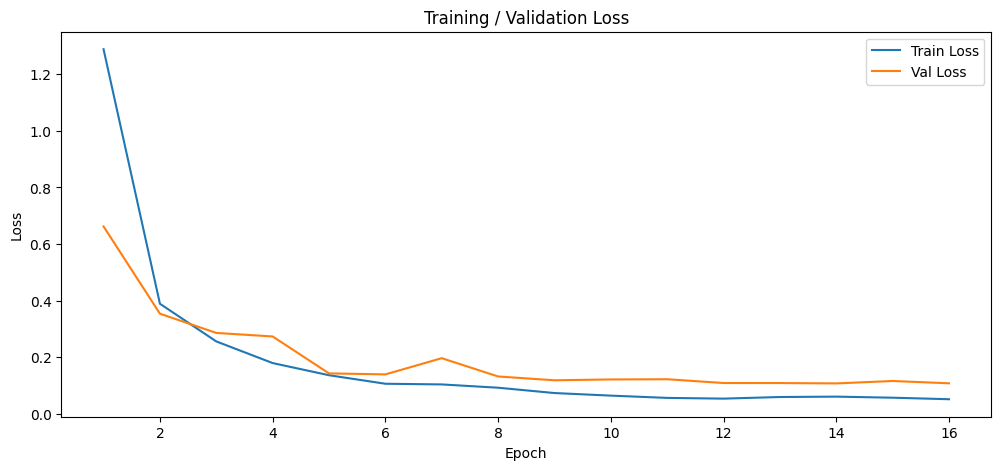

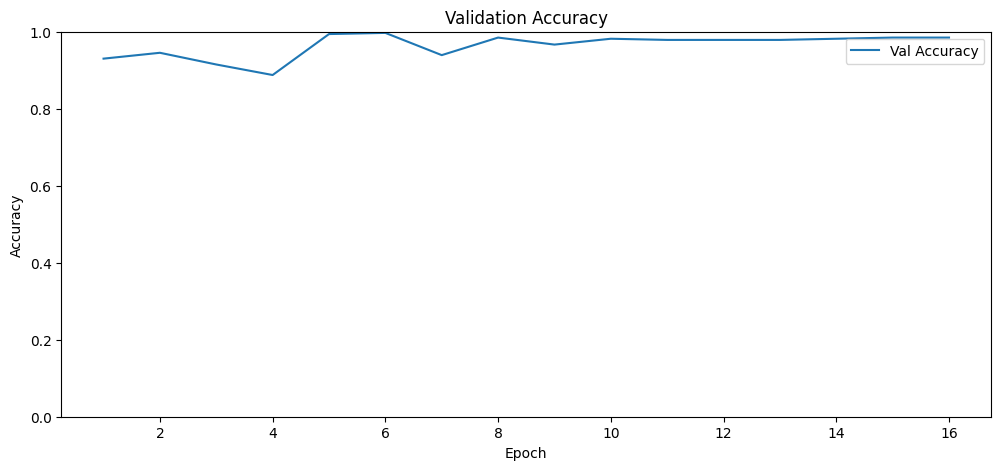

In [99]:
log = pd.read_csv(csv_log_path)

plt.figure(figsize=(12,5))
plt.plot(log['epoch'], log['train_loss'], label='Train Loss')
plt.plot(log['epoch'], log['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(log['epoch'], log['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.ylim(0,1)
plt.legend()
plt.show()

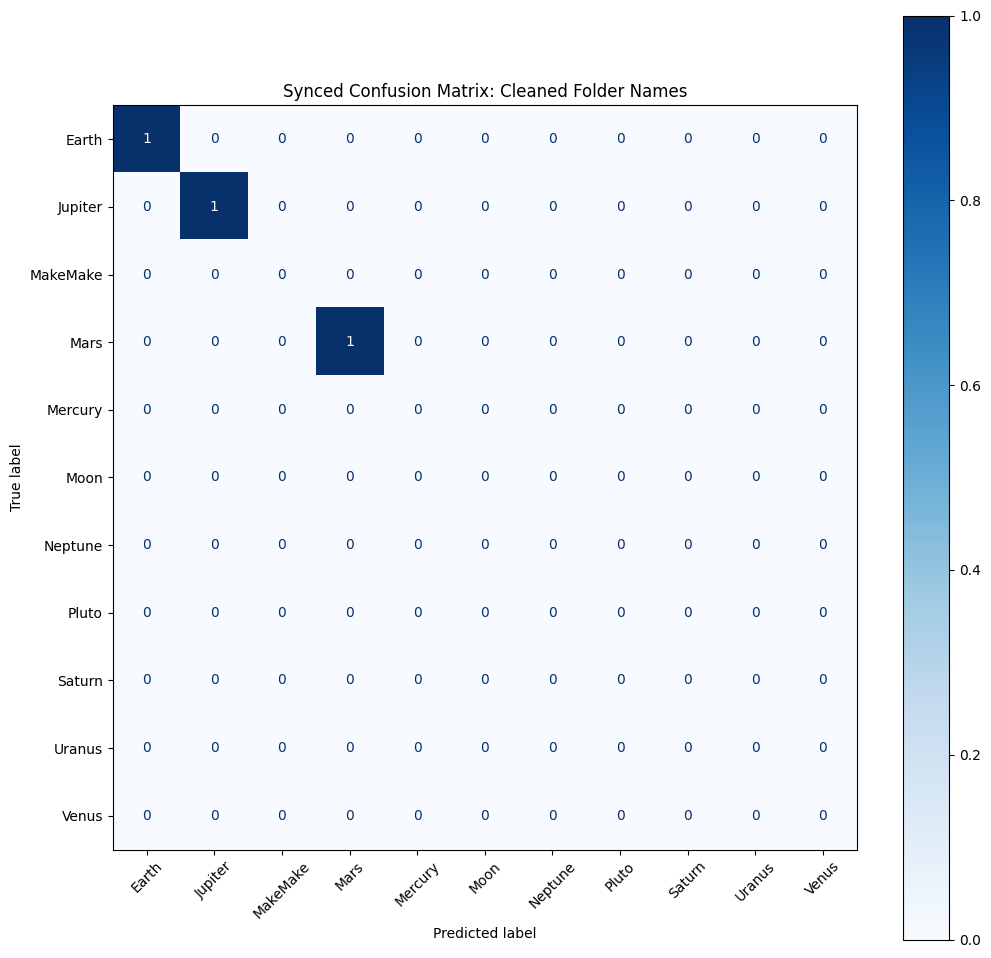

In [116]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Your MASTER list of 11 classes (as the model was trained)
full_classes = [
    'Earth', 'Jupiter', 'MakeMake', 'Mars', 'Mercury', 'Moon', 
    'Neptune', 'Pluto', 'Saturn', 'Uranus', 'Venus'
]

# 2. Get the mapping from YOUR test dataset
# This probably looks like: {'Test_Earth': 0, 'Test_Jupiter': 1, 'Test_Mars': 2}
test_mapping = test_dataset.class_to_idx  
idx_to_folder_name = {v: k for k, v in test_mapping.items()}

# 3. Re-map 'all_labels' to the 11-class master list
corrected_labels = []
for label in all_labels:
    # Get the folder name (e.g., 'Test_Earth')
    folder_name = idx_to_folder_name[label]
    
    # Clean the name: Remove 'Test_' to get just 'Earth'
    # .replace("Test_", "") handles your specific naming convention
    planet_name = folder_name.replace("Test_", "")
    
    try:
        global_idx = full_classes.index(planet_name)
        corrected_labels.append(global_idx)
    except ValueError:
        print(f"❌ Error: '{planet_name}' not found in full_classes list!")
        # Fallback: if names are totally different, we'll need to check your list again
        break

# 4. Generate the 11x11 Matrix
cm = confusion_matrix(corrected_labels, all_preds, labels=range(len(full_classes)))

# 5. Plotting
fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_classes)

disp.plot(
    include_values=True, 
    cmap=plt.cm.Blues, 
    ax=ax, 
    xticks_rotation=45, 
    values_format='d'
)

plt.title("Synced Confusion Matrix: Cleaned Folder Names")
plt.show()